In [21]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# Set specific sizes for axis labels and tick labels
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
# Set specific sizes for axis labels and tick labels
plt.rcParams['axes.labelsize'] = 14   # Fontsize of the x and y axis labels
plt.rcParams['xtick.labelsize'] = 14  # Fontsize of the x tick labels
plt.rcParams['ytick.labelsize'] = 14  # Fontsize of the y tick labels


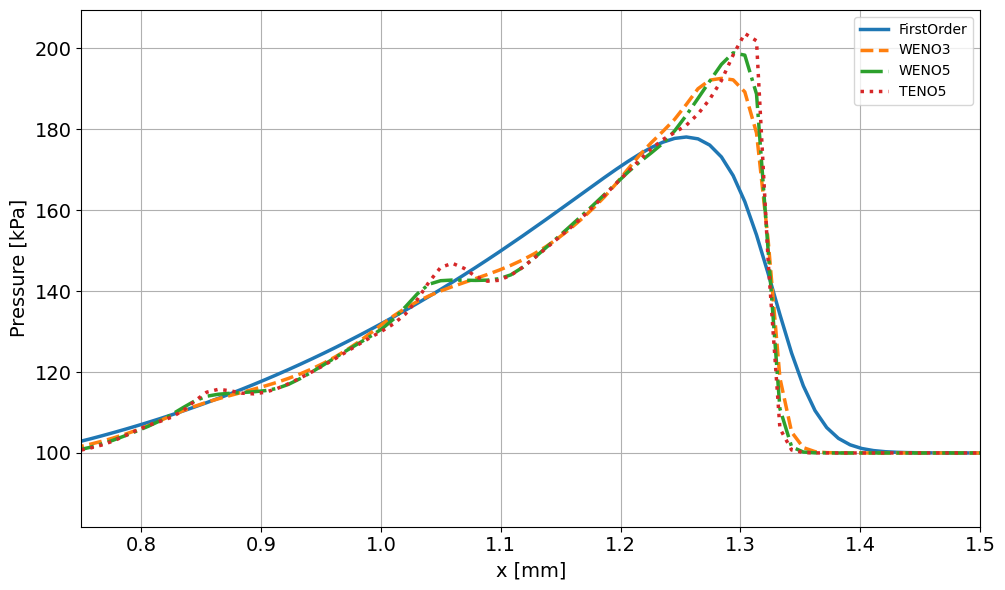


Requested slice value: 4.8828125e-06
Actual slice used: y = 4.882813e-06

Times used:


In [28]:
# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
run_folder = Path("runs/2026-03-26_19-52-30_512x512_omp12")
schemes = ["FirstOrder", "WENO3", "WENO5", "TENO5"]
field_name = "p"      # "p", "rho", "u", "v", etc.
step_index = -1       # last timestep

# Slice control:
# direction = "x"  -> plot field vs x at fixed y
# direction = "y"  -> plot field vs y at fixed x
direction = "x"

# Put either "center" or a number
slice_value = 0.0000048828125
# examples:
# slice_value = "center"
# slice_value = 0.001
# slice_value = 0.0035

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def load_step_csv(file_path):
    df = pd.read_csv(file_path, comment="#")

    x_vals = np.sort(df["x"].unique())
    y_vals = np.sort(df["y"].unique())

    nx = len(x_vals)
    ny = len(y_vals)

    fields = {}
    for col in ["rho", "u", "v", "p", "E", "rhou", "rhov", "H"]:
        fields[col] = df[col].to_numpy().reshape(ny, nx)

    with open(file_path, "r") as f:
        first_line = f.readline().strip()
    time = float(first_line.split("=")[1])

    return x_vals, y_vals, fields, time


def get_step_file(scheme, step_index=-1):
    data_dir = run_folder / f"{scheme}_512x512_omp12" / "data"

    files = sorted(
        glob.glob(str(data_dir / "step_*.csv")),
        key=lambda f: int(Path(f).stem.split("_")[1])
    )

    if not files:
        raise FileNotFoundError(f"No step files found for {scheme} in {data_dir}")

    return files[step_index]


def nearest_index(array, value):
    return int(np.argmin(np.abs(array - value)))


def extract_slice(x, y, field, direction="x", slice_value="center"):
    """
    direction = "x": field vs x at fixed y
    direction = "y": field vs y at fixed x
    """

    if direction == "x":
        if slice_value == "center":
            j = len(y) // 2
        else:
            j = nearest_index(y, float(slice_value))

        coord = x
        values = field[j, :]
        actual_slice = y[j]
        axis_label = "x [mm]"
        slice_label = f"y = {actual_slice:.6e}"

    elif direction == "y":
        if slice_value == "center":
            i = len(x) // 2
        else:
            i = nearest_index(x, float(slice_value))

        coord = y
        values = field[:, i]
        actual_slice = x[i]
        axis_label = "y [mm]"
        slice_label = f"x = {actual_slice:.6e}"

    else:
        raise ValueError("direction must be 'x' or 'y'")

    return coord, values, actual_slice, axis_label, slice_label


# --------------------------------------------------
# PLOT
# --------------------------------------------------
#plt.figure(figsize=(15, 12))

times = {}

line_styles = ["-", "--", "-.", ":"]
#markers = ["o", "s", "d", "^"]
linewidths = [2.5, 2.5, 2.5, 2.5]

for i, scheme in enumerate(schemes):
    file_to_plot = get_step_file(scheme, step_index=step_index)

    x, y, fields, time = load_step_csv(file_to_plot)

    coord, values, actual_slice, axis_label, slice_label = extract_slice(
        x, y, fields[field_name],
        direction=direction,
        slice_value=slice_value
    )

    plt.plot(
        coord*1000,
        values/1e3,
        linestyle=line_styles[i % len(line_styles)],
        markevery=40,  # <-- spacing between markers (key for readability)
        linewidth=linewidths[i % len(linewidths)],
        label=scheme
    )

ylabel_map = {
    "p": "Pressure [kPa]",
    "rho": "Density [kg/m$^3$]",
    "u": "u velocity [m/s]",
    "v": "v velocity [m/s]",
    "E": "Energy",
    "rhou": "rho*u",
    "rhov": "rho*v",
    "H": "Enthalpy"
}

plt.xlabel(axis_label)
plt.ylabel(ylabel_map.get(field_name, field_name))
#plt.title(f"{field_name} comparison across schemes at {slice_label}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0.75,1.5)
#plt.xticks(np.linspace(0.75,1.5,20))
#plt.savefig(f"Figures/allscheme_shock_slice_{direction}_2ms.png", dpi = 300)
plt.show()

print("\nRequested slice value:", slice_value)
print("Actual slice used:", slice_label)

print("\nTimes used:")
for scheme, time in times.items():
    print(f"{scheme}: {time:.6e} s")



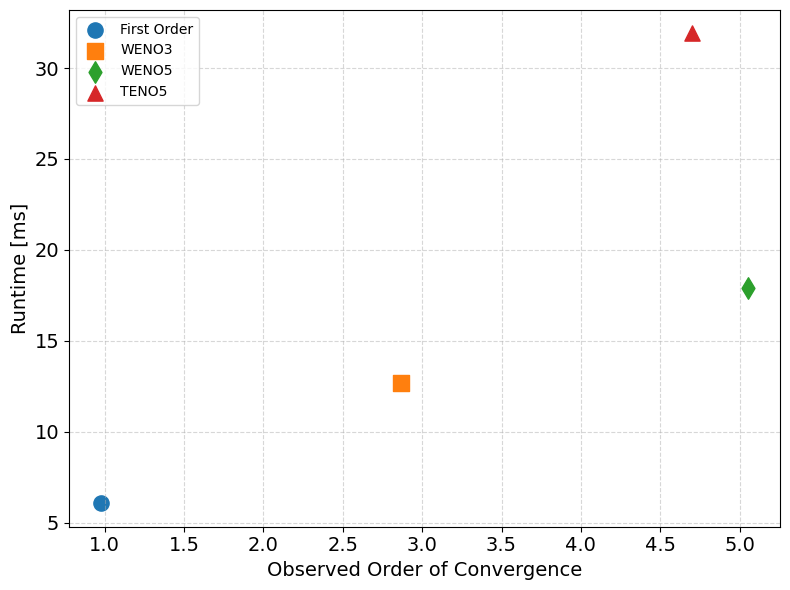

In [23]:
# Data
x = [6.07, 12.7, 17.9, 31.9]
y = [0.98, 2.87, 5.05, 4.70]
schemes = ["First Order", "WENO3", "WENO5", "TENO5"]

markers = ["o", "s", "d", "^"]

plt.figure(figsize=(8,6))

for i in range(len(schemes)):
    plt.scatter(
        y[i], x[i],
        marker=markers[i],
        s=120,                # bigger points
        label=schemes[i]
    )

plt.ylabel("Runtime [ms]")
plt.xlabel("Observed Order of Convergence")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"Figures/acc_vs_runtime.png", dpi = 300)
plt.show()

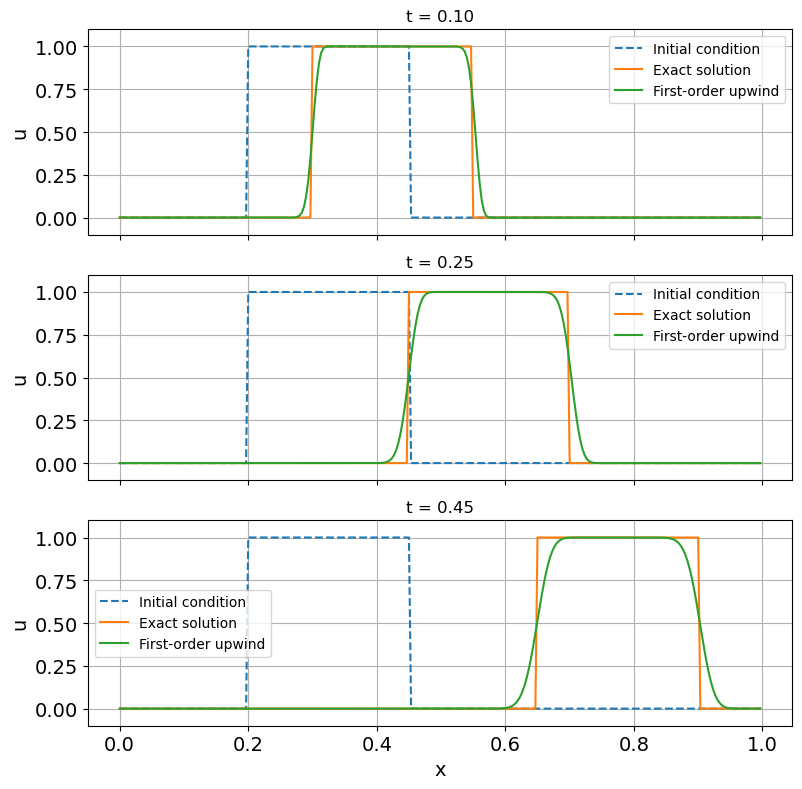

Saved figure to: first_order_upwind_diffusion.png


In [24]:
# --------------------------------------------------
# Representative first-order upwind diffusion demo
# --------------------------------------------------
# This script solves the 1-D linear advection equation
#
#     u_t + a u_x = 0
#
# using a first-order upwind method. The initial condition
# is a discontinuous step, so the numerical diffusion of the
# scheme is easy to see.
#
# Good slide/demo settings:
# - Keep CFL below 1
# - Compare initial, exact shifted step, and numerical result
# - Use a few output times to show progressive smearing
# --------------------------------------------------

# -------------------------
# User settings
# -------------------------
a = 1.0                 # advection speed
nx = 300                # number of grid points
x_min, x_max = 0.0, 1
cfl = 0.8               # CFL number
t_end = 1          # final time
plot_times = [0.10, 0.25, 0.45]  # times to store for plotting

# -------------------------
# Grid
# -------------------------
x = np.linspace(x_min, x_max, nx, endpoint=False)
dx = (x_max - x_min) / nx
dt = cfl * dx / abs(a)

# -------------------------
# Initial discontinuity
# -------------------------
def initial_condition(x):
    # Square wave / discontinuity
    return np.where((x >= 0.20) & (x <= 0.45), 1.0, 0.0)

# Exact solution for periodic advection
def exact_solution(x, t, a):
    x_shifted = (x - a * t - x_min) % (x_max - x_min) + x_min
    return initial_condition(x_shifted)

# First-order upwind step (for a > 0)
def upwind_step(u, a, dt, dx):
    sigma = a * dt / dx
    # periodic boundary through np.roll
    return u - sigma * (u - np.roll(u, 1))

# -------------------------
# Time march
# -------------------------
u0 = initial_condition(x)
u = u0.copy()
t = 0.0

saved = {0.0: u0.copy()}
target_times = sorted(plot_times)
next_idx = 0

while t < t_end - 1e-14:
    dt_step = min(dt, t_end - t)

    # If last step is shortened, keep the scheme consistent
    sigma = a * dt_step / dx
    u = u - sigma * (u - np.roll(u, 1))
    t += dt_step

    while next_idx < len(target_times) and t >= target_times[next_idx] - 1e-12:
        saved[target_times[next_idx]] = u.copy()
        next_idx += 1

# Ensure final time is stored
saved[t_end] = u.copy()

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(len(plot_times), 1, figsize=(8, 8), sharex=True)

if len(plot_times) == 1:
    axes = [axes]

for ax, tp in zip(axes, plot_times):
    u_num = saved[tp]
    u_ex = exact_solution(x, tp, a)

    ax.plot(x, u0, '--', label='Initial condition')
    ax.plot(x, u_ex, label='Exact solution')
    ax.plot(x, u_num, label='First-order upwind')

    ax.set_ylabel('u')
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f't = {tp:.2f}')
    ax.grid(True)
    ax.legend(loc='best')

axes[-1].set_xlabel('x')
#fig.suptitle('Numerical diffusion of a first-order upwind method on a discontinuity', y=0.98)
fig.tight_layout()

# Save figure
output_png = 'first_order_upwind_diffusion.png'
#plt.savefig(output_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure to: {output_png}")


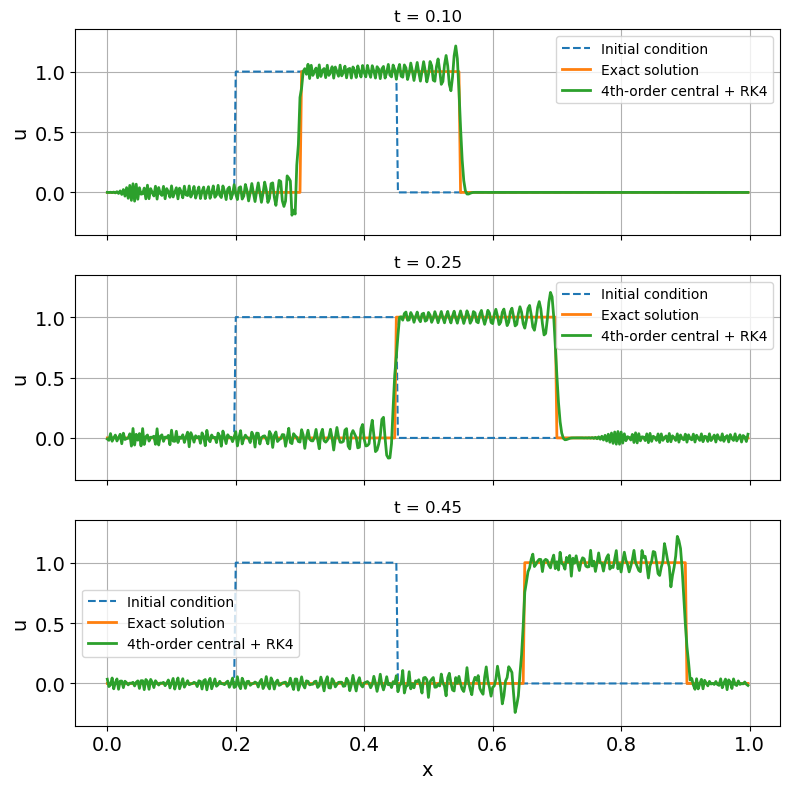

In [25]:
# --------------------------------------------------
# Representative high-order linear method demo
# --------------------------------------------------
# This solves the 1-D linear advection equation
#
#     u_t + a u_x = 0
#
# using:
#   - 4th-order central difference in space
#   - RK4 in time
#
# For a discontinuous initial condition, this linear
# high-order method shows dispersive oscillations near
# the jump instead of the strong smearing seen in a
# first-order upwind method.
# --------------------------------------------------

# -------------------------
# User settings
# -------------------------
a = 1.0
nx = 400
x_min, x_max = 0.0, 1.0
cfl = 0.2
t_end = 0.45
plot_times = [0.10, 0.25, 0.45]

# -------------------------
# Grid
# -------------------------
x = np.linspace(x_min, x_max, nx, endpoint=False)
L = x_max - x_min
dx = L / nx
dt = cfl * dx / abs(a)

# -------------------------
# Initial discontinuity
# -------------------------
def initial_condition(x):
    return np.where((x >= 0.20) & (x <= 0.45), 1.0, 0.0)

def exact_solution(x, t, a):
    x_shifted = (x - a * t - x_min) % L + x_min
    return initial_condition(x_shifted)

# -------------------------
# 4th-order central derivative
# -------------------------
# u_x ≈ (-u_{i+2} + 8u_{i+1} - 8u_{i-1} + u_{i-2}) / (12 dx)
def dudx_4th_central(u, dx):
    return (
        -np.roll(u, -2)
        + 8.0 * np.roll(u, -1)
        - 8.0 * np.roll(u,  1)
        + np.roll(u,  2)
    ) / (12.0 * dx)

def rhs(u):
    return -a * dudx_4th_central(u, dx)

def rk4_step(u, dt):
    k1 = rhs(u)
    k2 = rhs(u + 0.5 * dt * k1)
    k3 = rhs(u + 0.5 * dt * k2)
    k4 = rhs(u + dt * k3)
    return u + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# -------------------------
# Time march
# -------------------------
u0 = initial_condition(x)
u = u0.copy()
t = 0.0

saved = {0.0: u0.copy()}
target_times = sorted(plot_times)
next_idx = 0

while t < t_end - 1e-14:
    dt_step = min(dt, t_end - t)
    u = rk4_step(u, dt_step)
    t += dt_step

    while next_idx < len(target_times) and t >= target_times[next_idx] - 1e-12:
        saved[target_times[next_idx]] = u.copy()
        next_idx += 1

saved[t_end] = u.copy()

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(len(plot_times), 1, figsize=(8, 8), sharex=True)

if len(plot_times) == 1:
    axes = [axes]

for ax, tp in zip(axes, plot_times):
    u_num = saved[tp]
    u_ex = exact_solution(x, tp, a)

    ax.plot(x, u0, "--", linewidth=1.5, label="Initial condition")
    ax.plot(x, u_ex, linewidth=2.0, label="Exact solution")
    ax.plot(x, u_num, linewidth=2.0, label="4th-order central + RK4")

    ax.set_ylabel("u")
    ax.set_ylim(-0.35, 1.35)  # allow oscillation overshoot/undershoot to show
    ax.set_title(f"t = {tp:.2f}")
    ax.grid(True)
    ax.legend(loc="best")

axes[-1].set_xlabel("x")
'''fig.suptitle(
    "Dispersive oscillations of a high-order linear method at a discontinuity",
    y=0.98
)'''
fig.tight_layout()
plt.show()

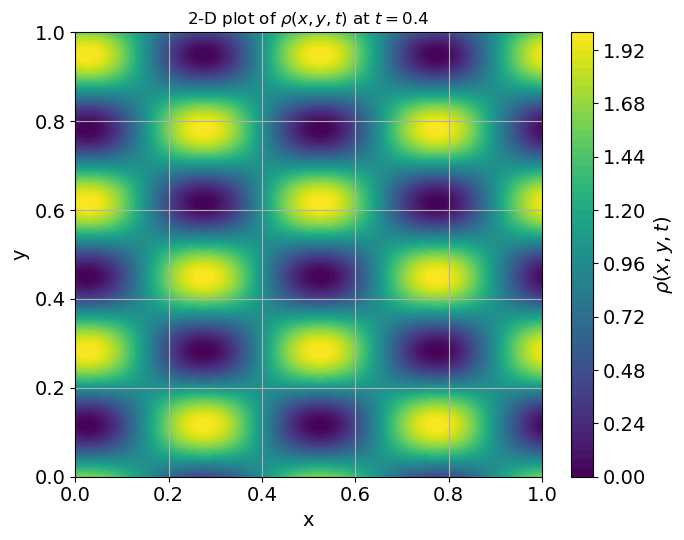

In [26]:
# --------------------------------------------------
# 2-D plot of:
#
# rho(x,y,t) = rho0
#            + sin( 2*pi*kx * (x - u0*t)/Lx )
#              sin( 2*pi*ky * (y - v0*t)/Ly )
# --------------------------------------------------

# -------------------------
# Parameters
# -------------------------
rho0 = 1.0
kx = 2
ky = 3
u0 = 1.0
v0 = 0.5

Lx = 1.0
Ly = 1.0

nx = 1000
ny = 1000

t = 0.4   # choose the time you want to plot

# -------------------------
# Grid
# -------------------------
x = np.linspace(0.0, Lx, nx)
y = np.linspace(0.0, Ly, ny)
X, Y = np.meshgrid(x, y)

# -------------------------
# Field
# -------------------------
rho = rho0 + np.sin(2*np.pi*kx*(X - u0*t)/Lx) * np.sin(2*np.pi*ky*(Y - v0*t)/Ly)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(7, 5.5))
contour = plt.contourf(X, Y, rho, levels=60, cmap="viridis")
plt.colorbar(contour, label=r'$\rho(x,y,t)$')

plt.xlabel('x')
plt.ylabel('y')
plt.title(rf'2-D plot of $\rho(x,y,t)$ at $t = {t}$')

plt.tight_layout()
plt.show()

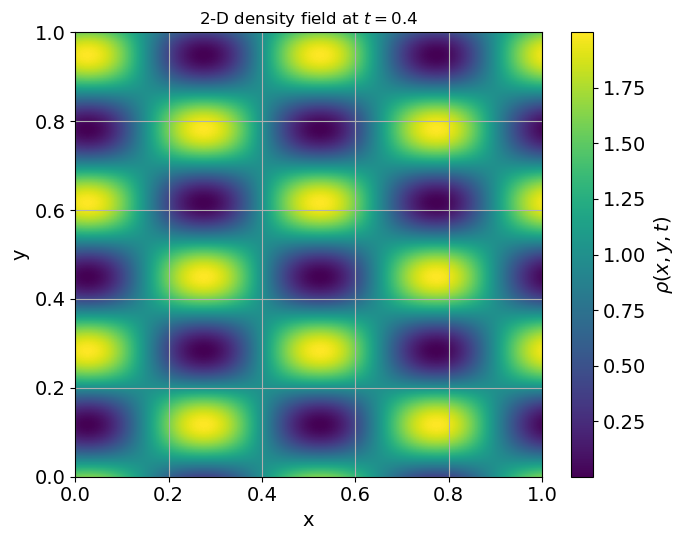

In [27]:
import numpy as np
import matplotlib.pyplot as plt

rho0 = 1.0
kx = 2
ky = 3
u0 = 1.0
v0 = 0.5
Lx = 1.0
Ly = 1.0
nx = 300
ny = 300
t = 0.4

x = np.linspace(0.0, Lx, nx)
y = np.linspace(0.0, Ly, ny)
X, Y = np.meshgrid(x, y)

rho = rho0 + np.sin(2*np.pi*kx*(X - u0*t)/Lx) * np.sin(2*np.pi*ky*(Y - v0*t)/Ly)

plt.figure(figsize=(7, 5.5))
plt.imshow(
    rho,
    extent=[0, Lx, 0, Ly],
    origin='lower',
    aspect='auto',
)
plt.colorbar(label=r'$\rho(x,y,t)$')
plt.xlabel('x')
plt.ylabel('y')
plt.title(rf'2-D density field at $t = {t}$')
plt.tight_layout()
plt.show()